# Ejercicios

**Estructura:** Para cada pregunta verás *(1) explicación → (2) código → (3) interpretación*.


## Simulación base

**Qué haremos**

Simularemos una cartera base con exposición y covariables típicas: edad del conductor `DrivAge`, edad del vehículo `VehAge`, potencia `VehPower` y región `Area`. Generaremos la **frecuencia** con un GLM Poisson (sobre `Exposure`) y la **severidad** con Gamma (enlace log). Esta base se usará en las 5 preguntas.

**Definiciones**
Frecuencia simulada por póliza (i):

$$
N_i \sim \mathrm{Poisson}(\mu_i),\quad \mu_i = \lambda_i \cdot \mathrm{Exposure}_i,\quad \log \lambda_i = X_i\beta 
$$

Severidad por siniestro:

$$
Y_{ij} \mid N_i>0 \sim \mathrm{Gamma}(\mu_i,\phi),\quad \log \mu_i = Z_i\alpha
$$

Guardaremos los parámetros “verdaderos” para comparaciones intuitivas (signos/orden).

In [1]:

import numpy as np, pandas as pd

rng = np.random.default_rng(2025)
n = 15000

Exposure = rng.uniform(0.5, 1.0, size=n)
DrivAge  = rng.integers(18, 75, size=n)
VehAge   = rng.integers(0, 20, size=n)
VehPower = rng.integers(4, 13, size=n)
Area     = rng.choice(list("ABCDEF"), size=n, p=[0.2,0.2,0.2,0.15,0.15,0.1])

# Parámetros de “verdad” para frecuencia
beta0, b_age, b_veh = -3.2, 0.015, -0.02
beta_area = {'A':0,'B':0.1,'C':0.2,'D':0.35,'E':0.45,'F':0.6}
eta = beta0 + b_age*DrivAge + b_veh*VehAge + np.array([beta_area[a] for a in Area])
lam = np.exp(eta)
mu_freq = lam * Exposure
ClaimNb = rng.poisson(mu_freq)

# Parámetros de “verdad” para severidad (Gamma)
alpha0, a_power = 8.0, 0.03
alpha_area = {'A':0,'B':0.02,'C':0.06,'D':0.08,'E':0.12,'F':0.15}
phi = 1.5  # dispersión (forma ~ 1/phi)

sev_mu = np.exp(alpha0 + a_power*VehPower + np.array([alpha_area[a] for a in Area]))
ClaimAmount = np.zeros(n)
for i in range(n):
    if ClaimNb[i] > 0:
        y = rng.gamma(shape=1/phi, scale=sev_mu[i]*phi, size=ClaimNb[i])
        ClaimAmount[i] = y.sum()

df = pd.DataFrame({
    "Exposure":Exposure, "DrivAge":DrivAge, "VehAge":VehAge,
    "VehPower":VehPower, "Area":Area, "ClaimNb":ClaimNb, "ClaimAmount":ClaimAmount
})
df["Area"] = df["Area"].astype("category")
df.head()


,Exposure,DrivAge,VehAge,VehPower,Area,ClaimNb,ClaimAmount
0,0.997229,43,17,12,E,0,0.0
1,0.691005,39,2,4,E,0,0.0
2,0.913574,26,15,12,B,0,0.0
3,0.918628,69,9,10,C,0,0.0
4,0.987905,68,16,5,D,0,0.0


**Lectura rápida**

- Riesgo base: `DrivAge` ↑ aumenta la frecuencia; `VehAge` ↑ la reduce; `Area` escala por niveles.
- Severidad: crece con `VehPower` y por `Area`.
- Estas señales nos permitirán chequear que lo que ajustemos con `Genero` haga sentido.


## Pregunta 1 · `Genero` con mayor siniestralidad en Hombres

**Pregunta 1 — Crear la variable `Genero` (Hombre/Mujer) con mayor siniestralidad en Hombres**

Agregaremos `Genero∈{Hombre,Mujer}` y **aumentaremos** la tasa de frecuencia de los Hombres multiplicando su λ por un factor (>1).

**Modelo conceptual**: si λ_i es la tasa base, para Hombres usamos λ_i^(H) = λ_i × e^δ con δ>0. Para Mujeres λ_i^(M)=λ_i.

Esto garantiza que, en promedio, Hombres presenten más siniestros que Mujeres (ceteris paribus).

In [2]:

# Crear Genero y aplicar sesgo en frecuencia para Hombres
Genero = np.where(rng.random(n) < 0.55, "Hombre", "Mujer")  # ligera mayor proporción de hombres
Genero = pd.Series(Genero, dtype="category")

delta = 0.20  # ~20% más riesgo en Hombres sobre Mujeres
lam_gen = lam * np.where(Genero=="Hombre", np.exp(delta), 1.0)
ClaimNb2 = rng.poisson(lam_gen * Exposure)

# Recalcular ClaimAmount manteniendo misma severidad media por póliza
ClaimAmount2 = np.zeros(n)
for i in range(n):
    if ClaimNb2[i] > 0:
        y = rng.gamma(shape=1/phi, scale=sev_mu[i]*phi, size=ClaimNb2[i])
        ClaimAmount2[i] = y.sum()

df["Genero"] = Genero
df["ClaimNb"] = ClaimNb2
df["ClaimAmount"] = ClaimAmount2

# Chequeo de tasa observada por género
rate_by_gender = (df.groupby("Genero")["ClaimNb"].sum() / df.groupby("Genero")["Exposure"].sum()).rename("rate")
rate_by_gender


Genero
Hombre    0.109942
Mujer     0.093522
Name: rate, dtype: float64

**Interpretación**

- La tasa observada por género debe ser **mayor en Hombres** que en Mujeres si el sesgo δ>0 se aplicó correctamente.
- En tu propia cartera, ajusta `delta` para calibrar el diferencial esperado entre géneros.


## Pregunta 2 · Frecuencia con `Genero` (ref=Hombre)

**Pregunta 2 — Incluir `Genero` en el modelo de frecuencia (referencia: Hombres)**

Ajustaremos un **GLM Poisson** con **offset** log(Exposure):

$$
\log \mu_i = \log(Exposure_i) + \beta_0 + \beta_1 DrivAge_i + \beta_2 VehAge_i + \gamma 1\{Genero_i=\text{Mujer}\} + \sum_k \beta_k^{(Area)} 1\{Area=k\}
$$

- Con `Treatment(reference='Hombre')` la categoría base es Hombres, por lo que exp(γ) es el **multiplicador** de Mujeres respecto a Hombres.
- Si simulamos Hombres con mayor tasa, esperamos **exp(γ)<1** (Mujer reduce la frecuencia vs Hombre).

In [3]:

import statsmodels.api as sm, statsmodels.formula.api as smf
import numpy as np

df["Area"] = df["Area"].cat.reorder_categories(list("ABCDEF"))
formula_freq = "ClaimNb ~ DrivAge + VehAge + C(Area, Treatment(reference='A')) + C(Genero, Treatment(reference='Hombre'))"

mod_p = smf.glm(formula=formula_freq, data=df,
                family=sm.families.Poisson(), offset=np.log(df["Exposure"]))
res_p = mod_p.fit()
print(res_p.summary())

# Predicción de tasa (lambda) y de frecuencia por exposición
df["lambda_hat"] = res_p.predict(df, offset=np.log(df["Exposure"])) / df["Exposure"]
df.groupby("Genero")["lambda_hat"].mean()


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:                15000
Model:                            GLM   Df Residuals:                    14991
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4064.4
Date:                Wed, 08 Oct 2025   Deviance:                       5887.0
Time:                        12:08:34   Pearson chi2:                 1.50e+04
No. Iterations:                     6   Pseudo R-squ. (CS):           0.009084
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

Genero
Hombre    0.109958
Mujer     0.093525
Name: lambda_hat, dtype: float64

**Interpretación**

- El coeficiente de `C(Genero)[T.Mujer]` debe ser **negativo** si las Mujeres presentan menor frecuencia que Hombres; su exponencial es el multiplicador.
- La media de `lambda_hat` por `Genero` debe preservar el orden (Hombre > Mujer) si el efecto es significativo.


## Pregunta 3 · Gráfica de tasa por género

**Pregunta 3 — Gráfica de la tasa por género**

Mostraremos la **tasa observada** por género con un intervalo aproximado. La tasa por grupo g es:

$$
\widehat{rate}_g = \frac{\sum_{i\in g} ClaimNb_i}{\sum_{i\in g} Exposure_i}
$$


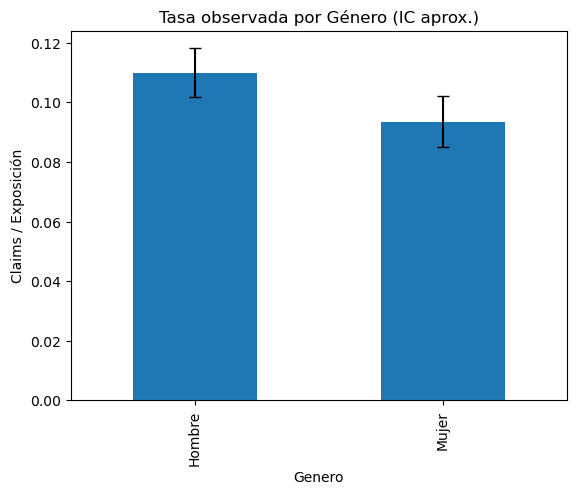

,rate
Genero,
Hombre,0.109942
Mujer,0.093522


In [4]:

import matplotlib.pyplot as plt

agg = df.groupby("Genero").agg(Claims=("ClaimNb","sum"), Expo=("Exposure","sum"))
agg["rate"] = agg["Claims"]/agg["Expo"]
# Error std aprox. para visualización (Poisson): sqrt(rate/Expo_total)
agg["se_rate"] = np.sqrt(agg["rate"]/agg["Expo"].clip(1e-9))

ax = agg["rate"].plot(kind="bar", yerr=1.96*agg["se_rate"], capsize=4)
plt.title("Tasa observada por Género (IC aprox.)")
plt.ylabel("Claims / Exposición")
plt.show()
agg[["rate"]]


**Interpretación**

- La barra de **Hombre** debería estar por encima de **Mujer**.
- Si los intervalos no se solapan mucho, el contraste es más marcado.


## Pregunta 4 · Severidad con `Genero` (Gamma + Lognormal)

**Pregunta 4 — Incluir `Genero` en el modelo de severidad**

Ajustaremos un GLM **Gamma** (enlace log) para la **severidad media por siniestro** $S_i = ClaimAmount_i / ClaimNb_i$ en pólizas con $ClaimNb>0$:

$$
\log E[S_i] = \alpha_0 + \alpha_1 VehPower_i + \sum_k \alpha_k^{(Area)} 1\{Area=k\} + \delta 1\{Genero_i=\text{Mujer}\} 
$$

- Con `Treatment(reference='Hombre')`, si exp(δ)<1, Mujeres tienen menor severidad que Hombres (y viceversa).
(Agregamos también una alternativa **Lognormal** sobre $log S_i$ para robustez.)

In [10]:

pos = df["ClaimNb"]>0
df_sev = df.loc[pos].copy()
df_sev["sev_mean"] = df_sev["ClaimAmount"]/df_sev["ClaimNb"]

form_gamma = "sev_mean ~ VehPower + C(Area, Treatment(reference='A')) + C(Genero, Treatment(reference='Hombre'))"
mod_g = smf.glm(formula=form_gamma, data=df_sev,
                family=sm.families.Gamma(link=sm.genmod.families.links.log()))
res_g = mod_g.fit()
print(res_g.summary())





                 Generalized Linear Model Regression Results                  
Dep. Variable:               sev_mean   No. Observations:                 1106
Model:                            GLM   Df Residuals:                     1098
Model Family:                   Gamma   Df Model:                            7
Link Function:                    log   Scale:                          1.4587
Method:                          IRLS   Log-Likelihood:                -10227.
Date:                Wed, 08 Oct 2025   Deviance:                       1942.9
Time:                        12:51:49   Pearson chi2:                 1.60e+03
No. Iterations:                    12   Pseudo R-squ. (CS):            0.01833
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

c:\Users\Eric_Daniel\anaconda3\envs\6.86x\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [11]:
# Alternativa lognormal
df_sev["log_sev"] = np.log(df_sev["sev_mean"])
res_ln = smf.ols("log_sev ~ VehPower + C(Area, Treatment(reference='A')) + C(Genero, Treatment(reference='Hombre'))", data=df_sev).fit()
print(res_ln.summary())

                            OLS Regression Results                            
Dep. Variable:                log_sev   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.965
Date:                Wed, 08 Oct 2025   Prob (F-statistic):             0.0568
Time:                        12:51:56   Log-Likelihood:                -2146.7
No. Observations:                1106   AIC:                             4309.
Df Residuals:                    1098   BIC:                             4349.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [9]:
# Predicciones de severidad (Gamma)
df["sev_hat_gamma"] = np.nan
df.loc[pos, "sev_hat_gamma"] = res_g.predict(df_sev)
df.groupby("Genero")["sev_hat_gamma"].mean()


Genero
Hombre    4407.717325
Mujer     3583.404092
Name: sev_hat_gamma, dtype: float64

**Interpretación**

- En Gamma, **exp(coef)** es el multiplicador de severidad vs referencia. Si `C(Genero)[T.Mujer]` < 0, entonces Mujeres ↓ severidad.
- La alternativa **Lognormal** debe mostrar un signo consistente para el coeficiente de `Genero` si el efecto es real.


## Pregunta 5 · Tarifa multiplicativa por género

**Pregunta 5 — Tarifa multiplicativa por género**

Construiremos multiplicadores por **frecuencia**, **severidad** y **total** relativos a la categoría base (Hombre). Para frecuencia usamos la tasa predicha λ̂; para severidad usamos μ̂ del modelo Gamma. Luego:

$$
factor^{(freq)}_g = \overline{\hat\lambda}_g / \overline{\hat\lambda}_{Hombre},\; factor^{(sev)}_g = \overline{\hat\mu}_g / \overline{\hat\mu}_{Hombre},\; factor^{(total)}_g = factor^{(freq)}_g \times factor^{(sev)}_g
$$


In [12]:

# Prima pura y factores por Género
df["pure_premium_hat"] = df["lambda_hat"] * df["sev_hat_gamma"]

# Factores por género (promedios de predicciones)
freq_factor = df.groupby("Genero")["lambda_hat"].mean() / df[df["Genero"]=="Hombre"]["lambda_hat"].mean()
sev_factor  = df.groupby("Genero")["sev_hat_gamma"].mean() / df[df["Genero"]=="Hombre"]["sev_hat_gamma"].mean()

import pandas as pd
tarifa_genero = (pd.DataFrame({"factor_freq":freq_factor, "factor_sev":sev_factor})
                 .assign(factor_total=lambda t: t["factor_freq"]*t["factor_sev"])
                 .reset_index())
tarifa_genero


,Genero,factor_freq,factor_sev,factor_total
0,Hombre,1.000000,1.000000,1.000000
1,Mujer,0.850552,0.812984,0.691485


**Interpretación**

- `factor_total` refleja el impacto combinado en la prima pura. Si el diferencial se introdujo solo en **frecuencia**, esperamos `factor_sev` ≈ 1 y la diferencia se concentre en `factor_freq`.
- En portafolios reales, estos factores se traducen directamente a una **tarifa multiplicativa** para agentes.
